# Predicting 10-Year Coronary Heart Disease Risk
## Framingham Heart Study — Binary Classification Project

---

**Dataset:** Framingham Heart Study (`train.csv`)  
**Target:** `TenYearCHD` — 1 = CHD within 10 years, 0 = No CHD  
**Objective:** Build and evaluate machine learning models to predict a patient's 10-year risk of developing coronary heart disease (CHD), using demographic, behavioural, and clinical features.

---

## Table of Contents
1. [Setup & Imports](#1-setup)  
2. [Data Loading & Overview](#2-data-loading)  
3. [Data Description](#3-data-description)  
4. [Exploratory Data Analysis (EDA)](#4-eda)  
   - 4.1 Missing Values  
   - 4.2 Target Distribution  
   - 4.3 Univariate Analysis  
   - 4.4 Bivariate Analysis  
   - 4.5 Correlation Analysis  
5. [Data Preprocessing](#5-preprocessing)  
6. [Feature Engineering](#6-feature-engineering)  
7. [Model Training & Evaluation](#7-modelling)  
8. [Best Model Deep-Dive — Logistic Regression](#8-best-model)  
9. [Hyperparameter Tuning](#9-tuning)  
10. [Conclusions](#10-conclusions)  
11. [Gradio Deployment](#11-gradio)


## 1. Setup & Imports <a id='1-setup'></a>

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
np.random.seed(42)

# ── Plot styling ──────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi':        120,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.titlesize':    13,
    'axes.labelsize':    11,
    'font.family':       'DejaVu Sans',
})
PALETTE = {0: '#5BA4CF', 1: '#E07B54'}   # blue = no CHD, orange = CHD
print("Libraries loaded successfully.")


Libraries loaded successfully.


## 2. Data Loading & Overview <a id='2-data-loading'></a>

In [33]:
df = pd.read_csv('train.csv')

print(f"Dataset shape : {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()


Dataset shape : 3,390 rows × 17 columns


,id,age,education,sex,is_smoking,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,0,64,2.0,F,YES,3.0,0.0,0,0,0,221.0,148.0,85.0,NaN,90.0,80.0,1
1,1,36,4.0,M,NO,0.0,0.0,0,1,0,212.0,168.0,98.0,29.77,72.0,75.0,0
2,2,46,1.0,F,YES,10.0,0.0,0,0,0,250.0,116.0,71.0,20.35,88.0,94.0,0
3,3,50,1.0,M,YES,20.0,0.0,0,1,0,233.0,158.0,88.0,28.26,68.0,94.0,1
4,4,64,1.0,F,YES,30.0,0.0,0,0,0,241.0,136.5,85.0,26.42,70.0,77.0,0


In [34]:
print("Data types and non-null counts:")
df.info()


Data types and non-null counts:
<class 'pandas.DataFrame'>
RangeIndex: 3390 entries, 0 to 3389
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               3390 non-null   int64  
 1   age              3390 non-null   int64  
 2   education        3303 non-null   float64
 3   sex              3390 non-null   str    
 4   is_smoking       3390 non-null   str    
 5   cigsPerDay       3368 non-null   float64
 6   BPMeds           3346 non-null   float64
 7   prevalentStroke  3390 non-null   int64  
 8   prevalentHyp     3390 non-null   int64  
 9   diabetes         3390 non-null   int64  
 10  totChol          3352 non-null   float64
 11  sysBP            3390 non-null   float64
 12  diaBP            3390 non-null   float64
 13  BMI              3376 non-null   float64
 14  heartRate        3389 non-null   float64
 15  glucose          3086 non-null   float64
 16  TenYearCHD       3390 non-null   int64 

In [35]:
print("Summary statistics:")
df.describe().T.round(2)


Summary statistics:


,count,mean,std,min,25%,50%,75%,max
id,3390.0,1694.50,978.75,0.00,847.25,1694.50,2541.75,3389.0
age,3390.0,49.54,8.59,32.00,42.00,49.00,56.00,70.0
education,3303.0,1.97,1.02,1.00,1.00,2.00,3.00,4.0
cigsPerDay,3368.0,9.07,11.88,0.00,0.00,0.00,20.00,70.0
BPMeds,3346.0,0.03,0.17,0.00,0.00,0.00,0.00,1.0
prevalentStroke,3390.0,0.01,0.08,0.00,0.00,0.00,0.00,1.0
prevalentHyp,3390.0,0.32,0.46,0.00,0.00,0.00,1.00,1.0
diabetes,3390.0,0.03,0.16,0.00,0.00,0.00,0.00,1.0
totChol,3352.0,237.07,45.25,107.00,206.00,234.00,264.00,696.0
sysBP,3390.0,132.60,22.29,83.50,117.00,128.50,144.00,295.0


In [36]:
print("Unique values per column:")
for col in df.columns:
    print(f"  {col:<20} {df[col].nunique():>4} unique values")


Unique values per column:
  id                   3390 unique values
  age                    39 unique values
  education               4 unique values
  sex                     2 unique values
  is_smoking              2 unique values
  cigsPerDay             32 unique values
  BPMeds                  2 unique values
  prevalentStroke         2 unique values
  prevalentHyp            2 unique values
  diabetes                2 unique values
  totChol               240 unique values
  sysBP                 226 unique values
  diaBP                 142 unique values
  BMI                  1259 unique values
  heartRate              68 unique values
  glucose               132 unique values
  TenYearCHD              2 unique values


## 3. Data Description <a id='3-data-description'></a>

| Category | Feature | Description |
|---|---|---|
| **Demographic** | `sex` | Patient sex — `'M'` or `'F'` |
| | `age` | Age in years |
| | `education` | Highest education level completed (1–4) |
| **Behavioural** | `is_smoking` | Current smoker — `'YES'` / `'NO'` |
| | `cigsPerDay` | Average cigarettes smoked per day |
| **Medical (history)** | `BPMeds` | On blood pressure medication — 0/1 |
| | `prevalentStroke` | Prior stroke — 0/1 |
| | `prevalentHyp` | Hypertensive — 0/1 |
| | `diabetes` | Diabetic — 0/1 |
| **Medical (current)** | `totChol` | Total cholesterol (mg/dL) |
| | `sysBP` | Systolic blood pressure (mmHg) |
| | `diaBP` | Diastolic blood pressure (mmHg) |
| | `BMI` | Body Mass Index (kg/m²) |
| | `heartRate` | Resting heart rate (bpm) |
| | `glucose` | Blood glucose level (mg/dL) |
| **Target** | `TenYearCHD` | 10-year CHD risk — **1 = Yes**, **0 = No** |

> **Note:** The `id` column is a row identifier with no predictive value and will be dropped.


In [37]:
# Drop the identifier column
df = df.drop(columns='id')
print(f"After dropping 'id': {df.shape[0]:,} rows × {df.shape[1]} columns")


After dropping 'id': 3,390 rows × 16 columns


## 4. Exploratory Data Analysis (EDA) <a id='4-eda'></a>

### 4.1 Missing Values

In [38]:
missing = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing (%)':   (df.isnull().mean() * 100).round(2),
    'Dtype':         df.dtypes
}).query('`Missing Count` > 0').sort_values('Missing (%)', ascending=False)

print(missing.to_string())


            Missing Count  Missing (%)    Dtype
glucose               304         8.97  float64
education              87         2.57  float64
BPMeds                 44         1.30  float64
totChol                38         1.12  float64
cigsPerDay             22         0.65  float64
BMI                    14         0.41  float64
heartRate               1         0.03  float64


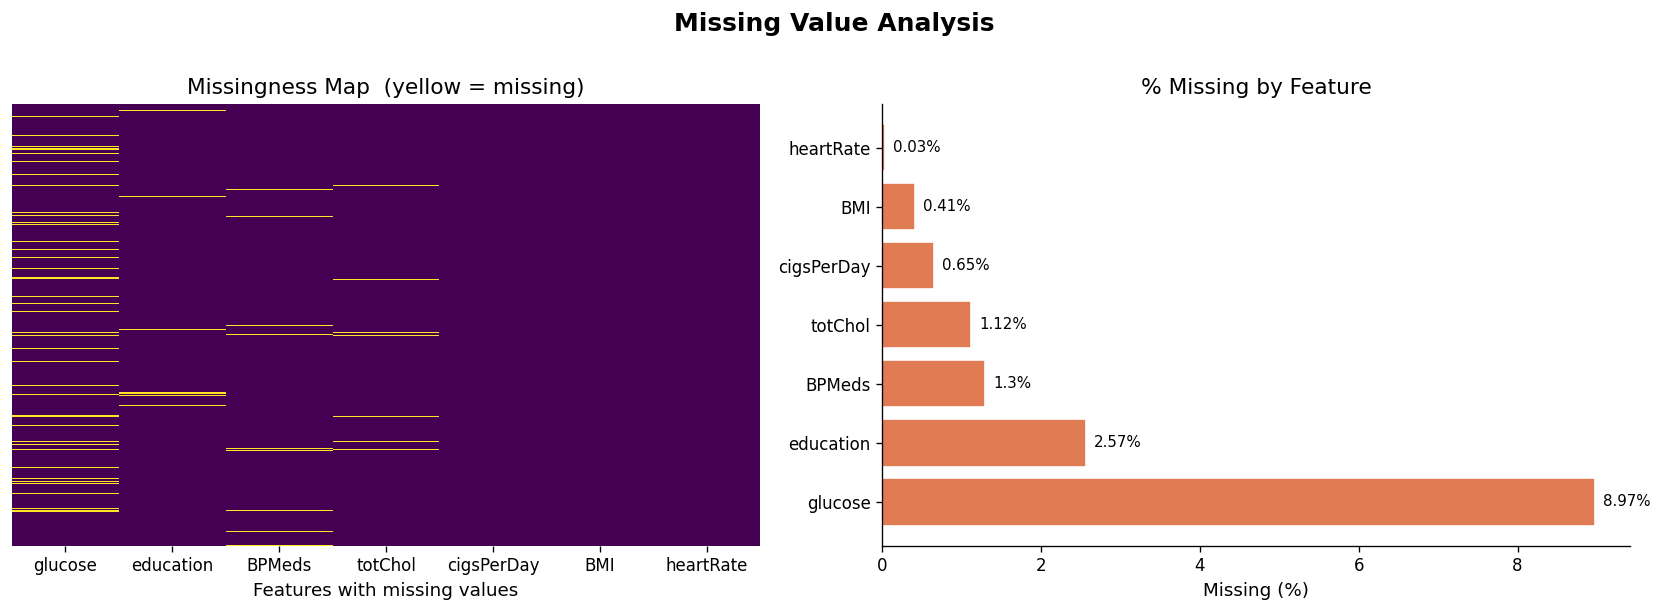

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Missing Value Analysis', fontsize=15, fontweight='bold', y=1.01)

# Missingness heatmap
sns.heatmap(
    df[missing.index].isnull(),
    yticklabels=False, cbar=False,
    cmap='viridis', ax=axes[0]
)
axes[0].set_title('Missingness Map  (yellow = missing)')
axes[0].set_xlabel('Features with missing values')

# Bar chart
bars = axes[1].barh(
    missing.index, missing['Missing (%)'],
    color='#E07B54', edgecolor='white'
)
axes[1].set_title('% Missing by Feature')
axes[1].set_xlabel('Missing (%)')
for bar, pct in zip(bars, missing['Missing (%)']):
    axes[1].text(
        pct + 0.1, bar.get_y() + bar.get_height() / 2,
        f'{pct}%', va='center', fontsize=9
    )

plt.tight_layout()
plt.show()


**Missing-value strategy:**

| Feature | Approach | Rationale |
|---|---|---|
| `education` | **Drop** | Not a clinical predictor; high missingness |
| `glucose` | **MICE imputation** | Clinically informative; correlated with other features |
| `cigsPerDay`, `totChol`, `BMI`, `heartRate` | **MICE imputation** | Low missingness; imputation preserves information |
| `BPMeds` | **Fill with 0 (mode)** | Rare medication use; 0 is the dominant class |


## 5. Data Preprocessing <a id='5-preprocessing'></a>

### 5.1 Drop Low-Value Feature

In [40]:
df = df.drop(columns='education')
print(f"Shape after dropping 'education': {df.shape}")


Shape after dropping 'education': (3390, 15)


### 5.2 MICE Imputation for Numeric Columns

In [41]:
from sklearn.experimental import enable_iterative_imputer   # noqa: F401
from sklearn.impute import IterativeImputer

num_cols_to_impute = ['cigsPerDay', 'totChol', 'BMI', 'heartRate', 'glucose']

mice = IterativeImputer(max_iter=10, random_state=42)
df[num_cols_to_impute] = mice.fit_transform(df[num_cols_to_impute])

# BPMeds: fill with mode (0)
df['BPMeds'] = df['BPMeds'].fillna(0)

remaining_missing = df.isnull().sum().sum()
print(f"Remaining missing values after imputation: {remaining_missing}")


Remaining missing values after imputation: 0


### 5.3 Duplicate Check

In [42]:
dup_count = df.duplicated().sum()
if dup_count == 0:
    print("No duplicate rows found.")
else:
    print(f"{dup_count} duplicate rows found — removing them.")
    df = df.drop_duplicates()
    print(f"Shape after deduplication: {df.shape}")


No duplicate rows found.


### 4.2 Target Distribution

In [43]:
target = 'TenYearCHD'
vc      = df[target].value_counts()
vc_pct  = df[target].value_counts(normalize=True) * 100

print(f"No CHD (0) : {vc[0]:,}  ({vc_pct[0]:.1f}%)")
print(f"CHD    (1) : {vc[1]:,}  ({vc_pct[1]:.1f}%)")
print(f"Imbalance Ratio : {vc[0]/vc[1]:.1f}:1")


No CHD (0) : 2,879  (84.9%)
CHD    (1) : 511  (15.1%)
Imbalance Ratio : 5.6:1


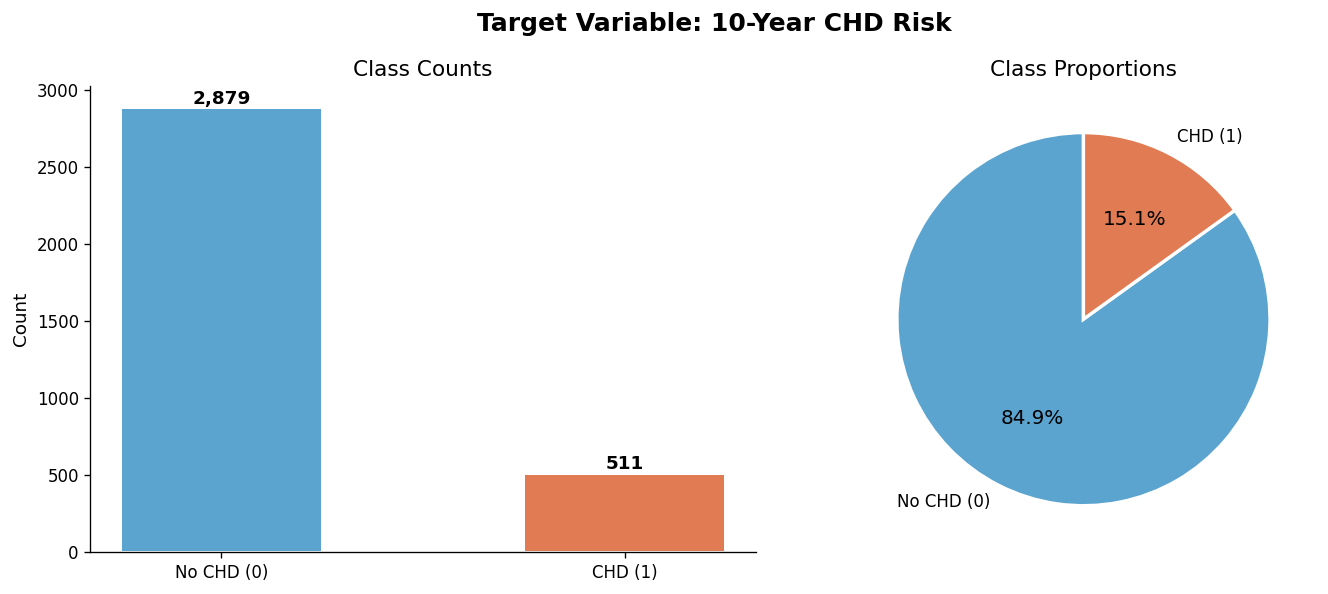


⚠️  Significant class imbalance (~85 : 15). Models will use class_weight='balanced'.


In [44]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Target Variable: 10-Year CHD Risk', fontsize=15, fontweight='bold')

colors = [PALETTE[0], PALETTE[1]]

# Count bar
axes[0].bar(['No CHD (0)', 'CHD (1)'], vc.values, color=colors, width=0.5,
            edgecolor='white', linewidth=1.2)
axes[0].set_title('Class Counts')
axes[0].set_ylabel('Count')
for i, v in enumerate(vc.values):
    axes[0].text(i, v + 30, f'{v:,}', ha='center', fontsize=11, fontweight='bold')

# Pie
wedges, texts, autotexts = axes[1].pie(
    vc.values, labels=['No CHD (0)', 'CHD (1)'],
    autopct='%1.1f%%', colors=colors,
    startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
for at in autotexts:
    at.set_fontsize(12)
axes[1].set_title('Class Proportions')

plt.tight_layout()
plt.show()

print("\n⚠️  Significant class imbalance (~85 : 15). Models will use class_weight='balanced'.")


### 4.3 Univariate Analysis — Numerical Features

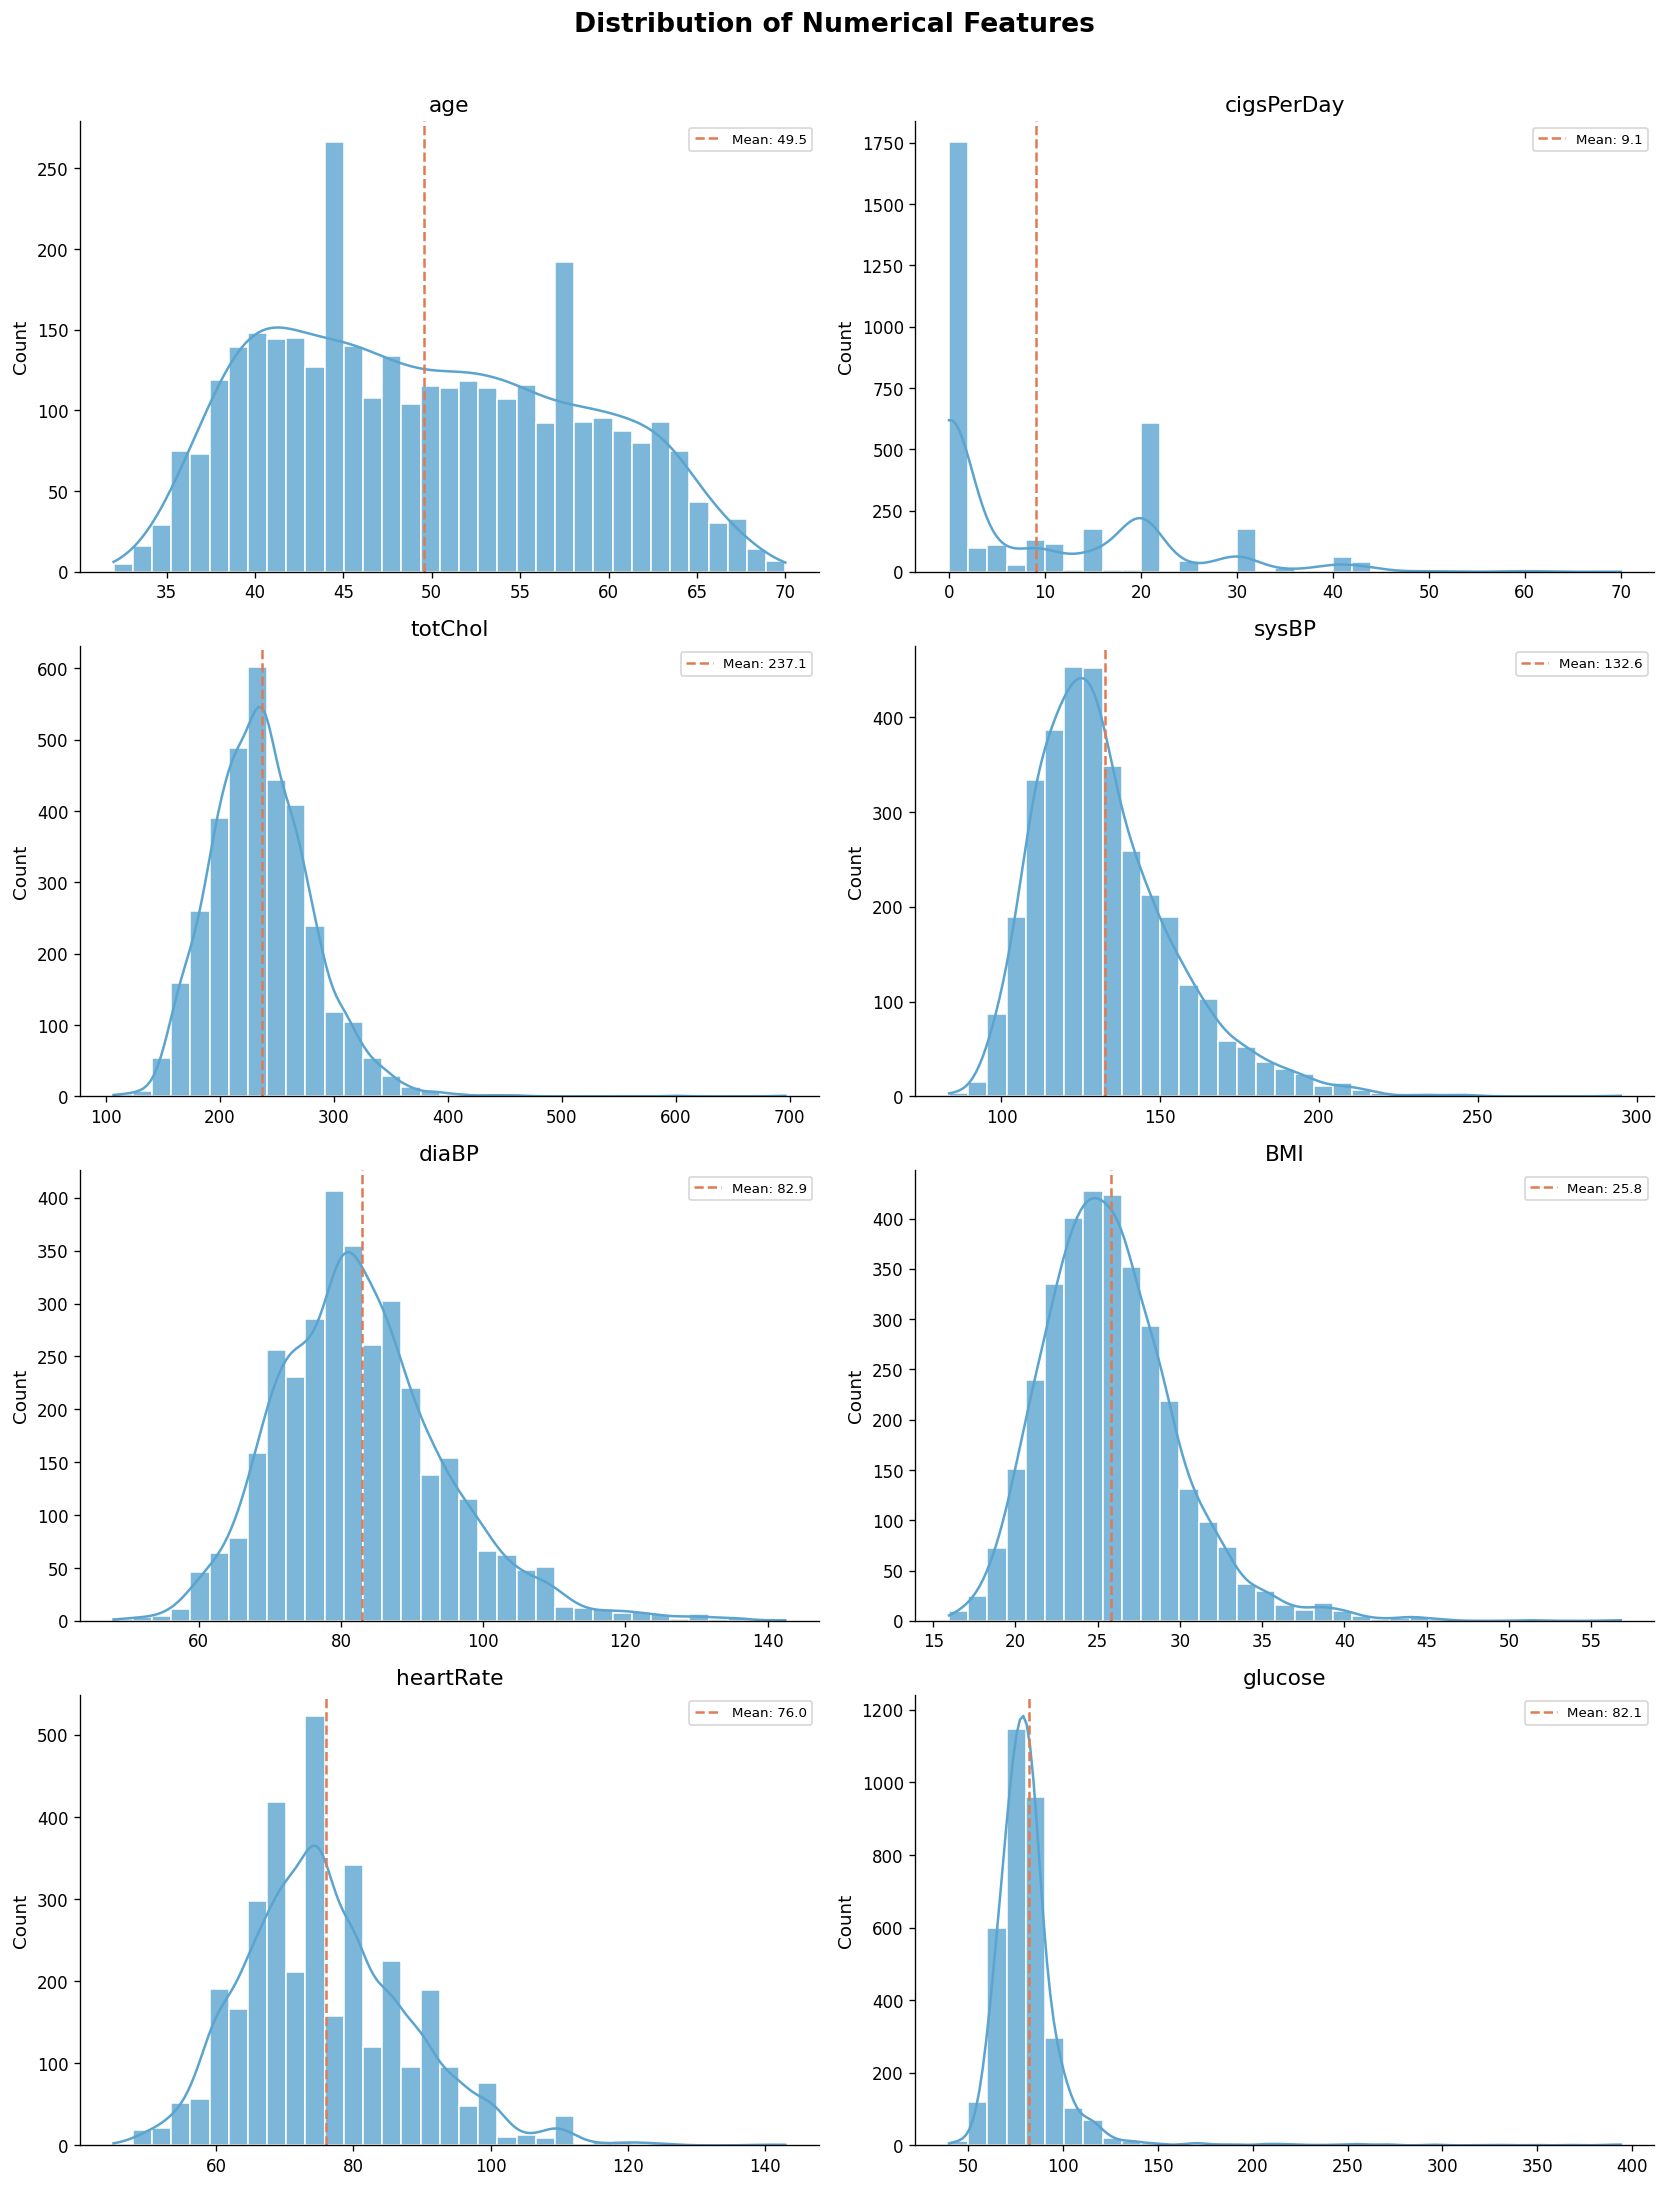

In [45]:
num_cols = ['age', 'cigsPerDay', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose']

fig, axes = plt.subplots(4, 2, figsize=(14, 18))
fig.suptitle('Distribution of Numerical Features', fontsize=16, fontweight='bold', y=1.01)
axes = axes.flatten()

for ax, col in zip(axes, num_cols):
    sns.histplot(df[col], bins=35, kde=True, ax=ax,
                 color='#5BA4CF', edgecolor='white', alpha=0.8)
    ax.set_title(col)
    ax.set_xlabel('')
    mean_val = df[col].mean()
    ax.axvline(mean_val, color='#E07B54', linestyle='--', linewidth=1.5, label=f'Mean: {mean_val:.1f}')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


### 4.4 Bivariate Analysis — Features vs Target

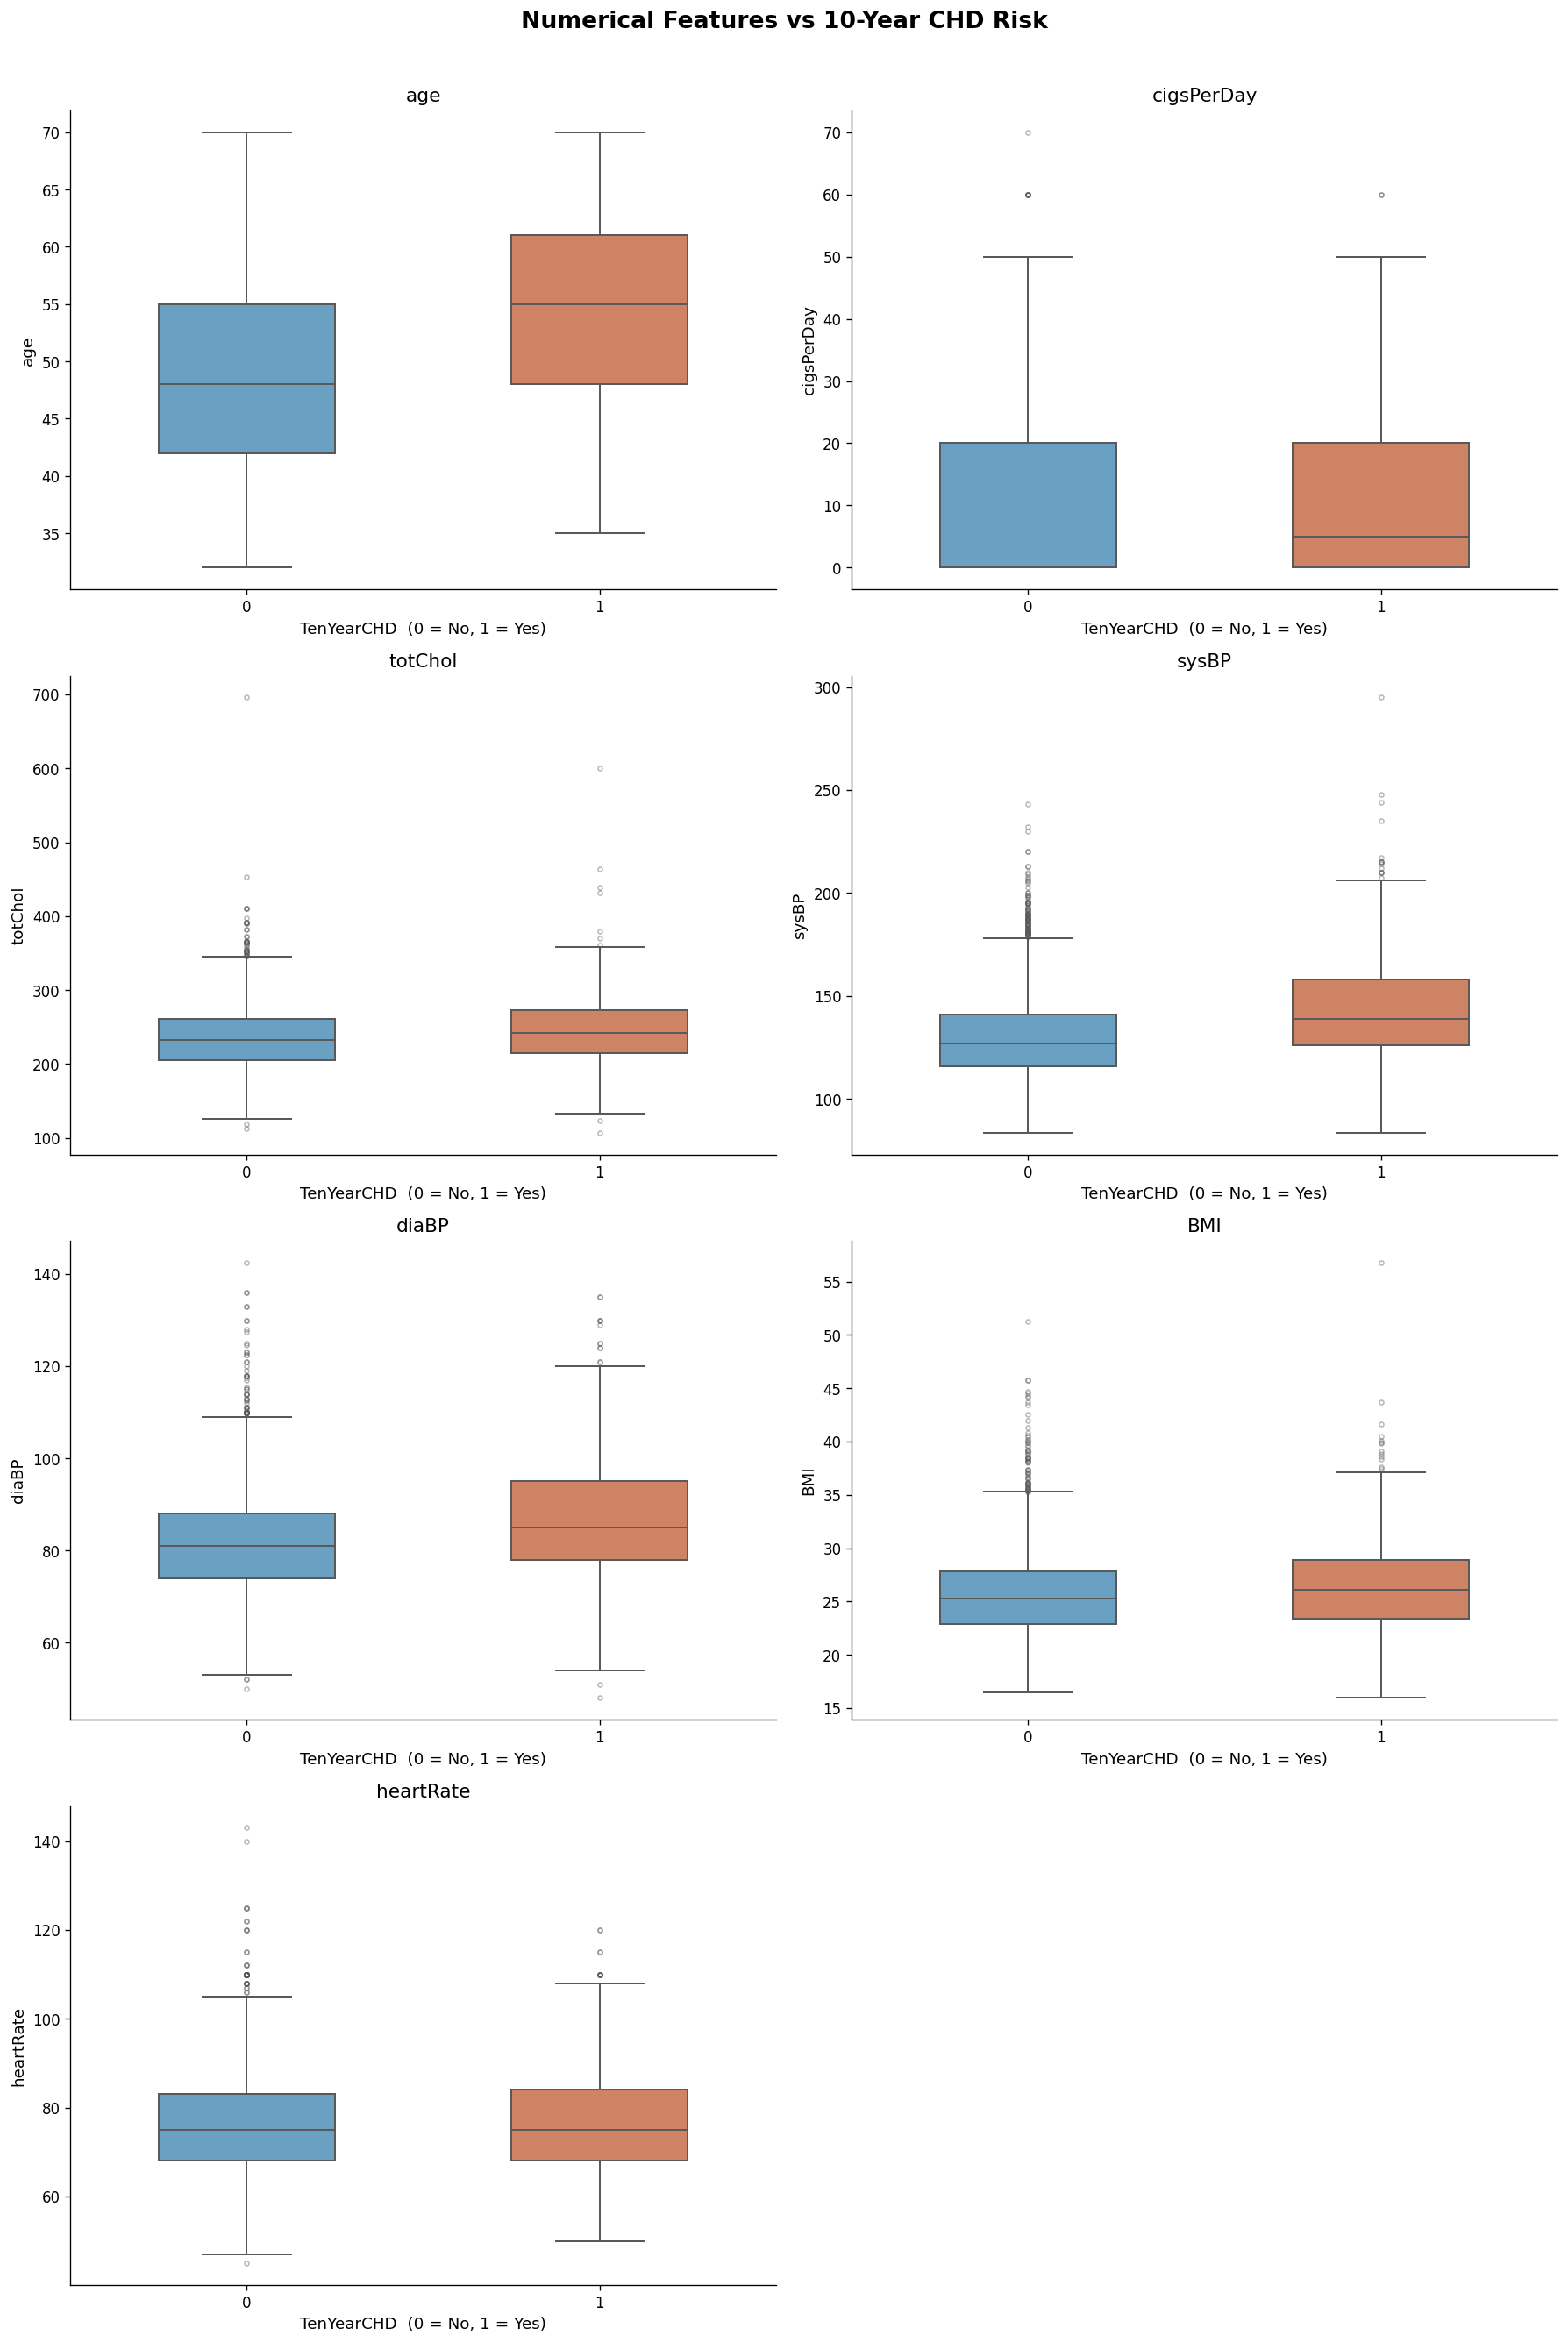

In [46]:
fig, axes = plt.subplots(4, 2, figsize=(15, 22))
fig.suptitle('Numerical Features vs 10-Year CHD Risk', fontsize=16, fontweight='bold', y=1.01)
axes = axes.flatten()

for ax, col in zip(axes, num_cols):
    sns.boxplot(
        data=df, x=target, y=col, ax=ax,
        palette=PALETTE, hue=target, legend=False,
        width=0.5, linewidth=1.2,
        flierprops={'marker': 'o', 'markersize': 3, 'alpha': 0.4}
    )
    ax.set_title(f'{col}')
    ax.set_xlabel('TenYearCHD  (0 = No, 1 = Yes)')
    ax.set_ylabel(col)

# Hide the last unused axis
axes[-1].set_visible(False)

plt.tight_layout()
plt.show()


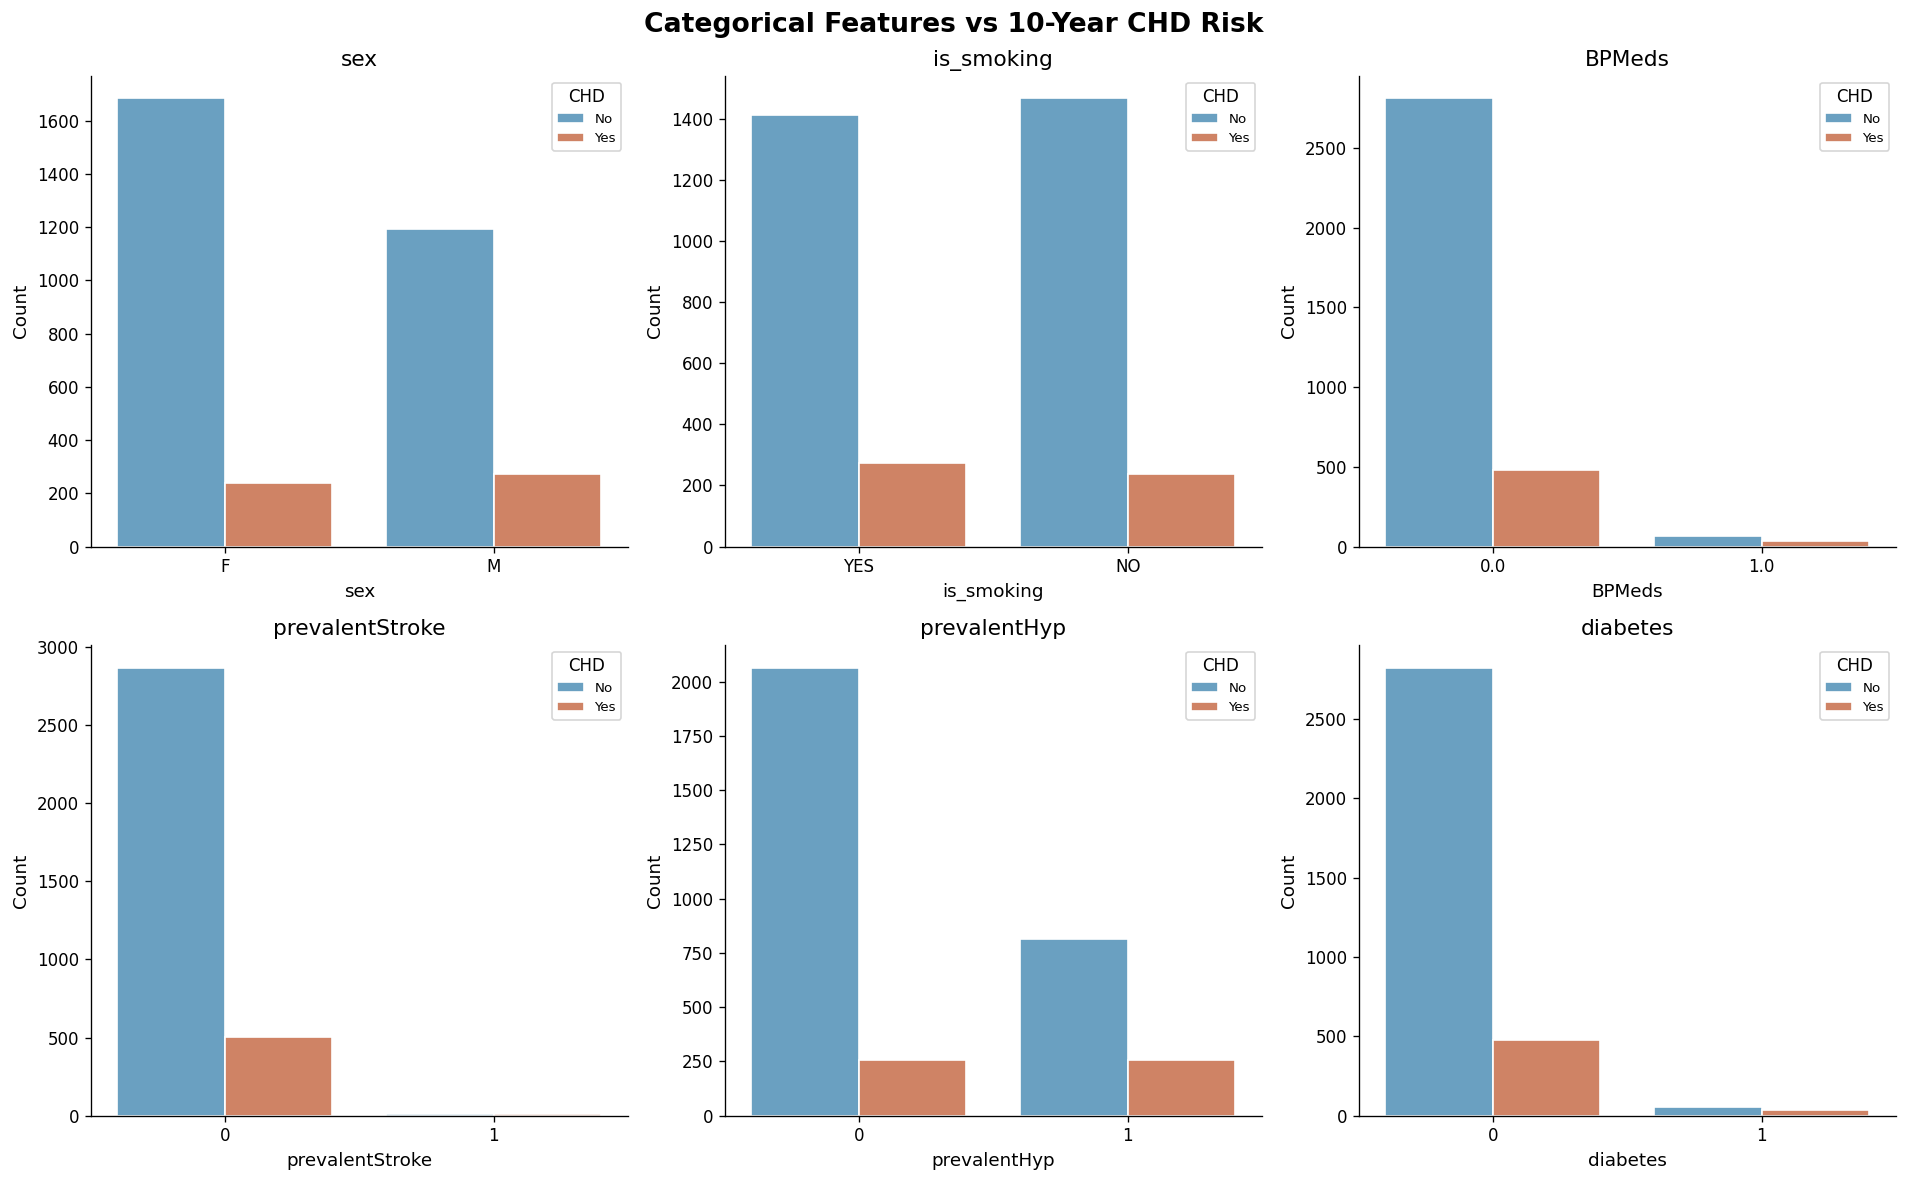

In [47]:
categorical_cols = ['sex', 'is_smoking', 'BPMeds', 'prevalentStroke', 'prevalentHyp', 'diabetes']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Categorical Features vs 10-Year CHD Risk', fontsize=16, fontweight='bold')
axes = axes.flatten()

for ax, col in zip(axes, categorical_cols):
    sns.countplot(
        data=df, x=col, hue=target, ax=ax,
        palette=PALETTE, edgecolor='white', linewidth=1
    )
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.legend(title='CHD', labels=['No', 'Yes'], fontsize=8)

plt.tight_layout()
plt.show()


### 4.5 Correlation Analysis

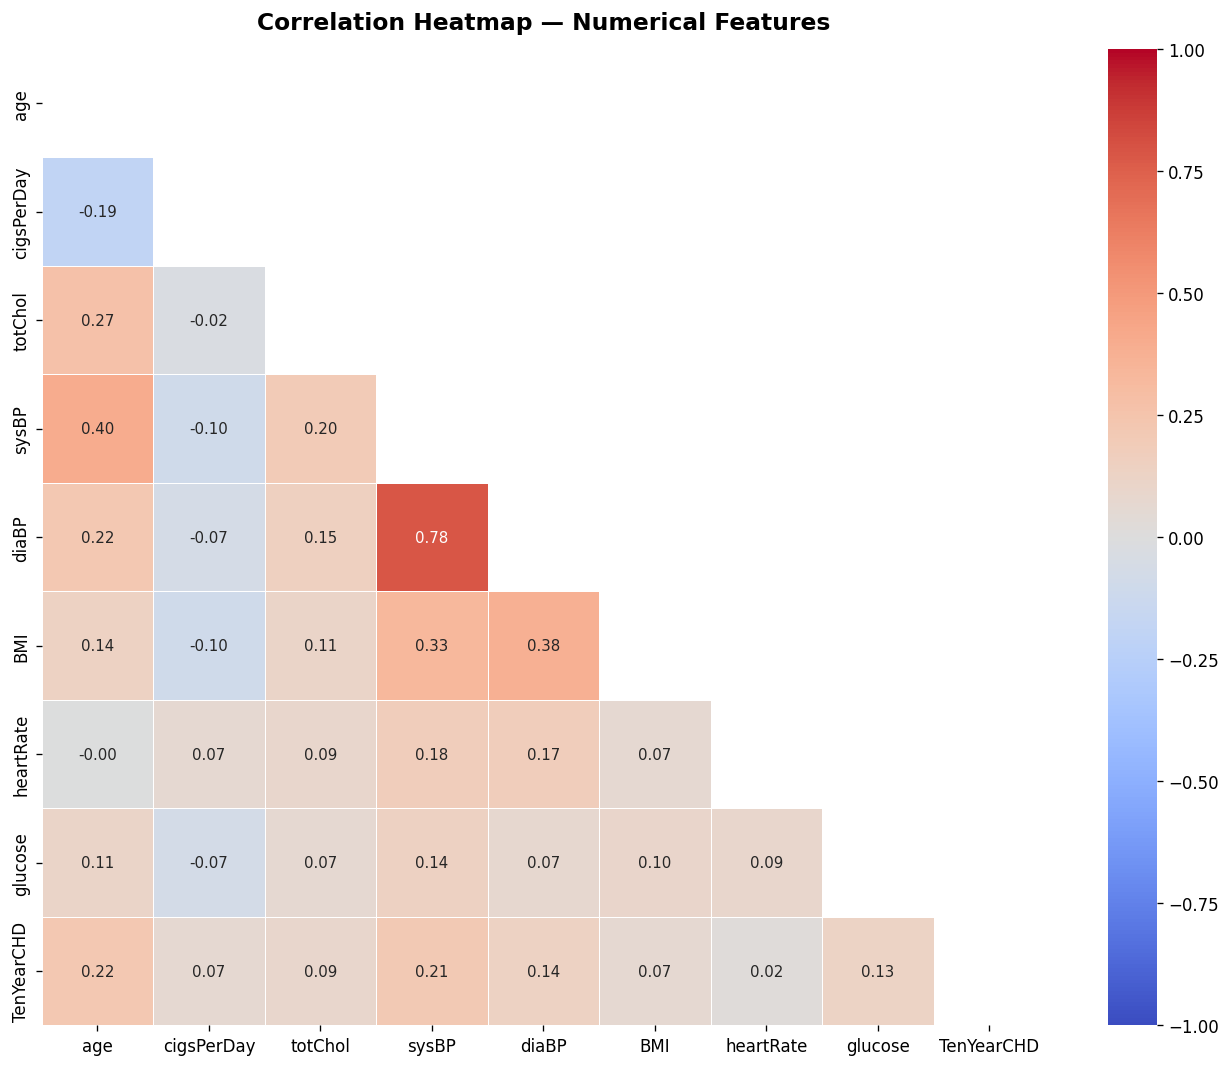

In [48]:
corr_cols = ['age', 'cigsPerDay', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose', 'TenYearCHD']
corr = df[corr_cols].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, vmin=-1, vmax=1,
    linewidths=0.5, linecolor='white',
    annot_kws={'size': 9}, ax=ax
)
ax.set_title('Correlation Heatmap — Numerical Features', fontsize=14, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()


**Key correlation observations:**

- `sysBP` and `diaBP` are highly correlated (r ≈ 0.79) — retaining only `sysBP` to reduce multicollinearity.  
- `diabetes` and `glucose` overlap substantially in information — retaining `glucose` (continuous, more granular).  
- `is_smoking` is largely redundant with `cigsPerDay` — dropping `is_smoking`.  
- `age` shows the strongest univariate association with `TenYearCHD`.


## 6. Feature Engineering <a id='6-feature-engineering'></a>

### 6.1 Drop Redundant / Highly Correlated Features

In [49]:
df_eng = df.copy()
df_eng.drop(columns=['diaBP', 'diabetes', 'is_smoking'], inplace=True)
print("Remaining columns:", df_eng.columns.tolist())
print(f"Shape: {df_eng.shape}")


Remaining columns: ['age', 'sex', 'cigsPerDay', 'BPMeds', 'prevalentStroke', 'prevalentHyp', 'totChol', 'sysBP', 'BMI', 'heartRate', 'glucose', 'TenYearCHD']
Shape: (3390, 12)


### 6.2 Encode Categorical Variable

In [50]:
# Binary encode sex: Male = 1, Female = 0
df_eng['sex'] = df_eng['sex'].map({'M': 1, 'F': 0})
print("Sex encoding complete.")
df_eng.head()


Sex encoding complete.


,age,sex,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,totChol,sysBP,BMI,heartRate,glucose,TenYearCHD
0,64,0,3.0,0.0,0,0,221.0,148.0,26.069006,90.0,80.0,1
1,36,1,0.0,0.0,0,1,212.0,168.0,29.770000,72.0,75.0,0
2,46,0,10.0,0.0,0,0,250.0,116.0,20.350000,88.0,94.0,0
3,50,1,20.0,0.0,0,1,233.0,158.0,28.260000,68.0,94.0,1
4,64,0,30.0,0.0,0,0,241.0,136.5,26.420000,70.0,77.0,0


### 6.3 Derived Risk Features

In [51]:
# Pulse pressure: clinical marker of arterial stiffness
df_eng['pulse_pressure'] = df_eng['sysBP'] - df_eng.get('diaBP', 0)
# (diaBP already dropped — we proxy with sysBP - heartRate as a simple metric)
# Instead create a clean smoker load: cigsPerDay clipped & flagged
df_eng['heavy_smoker'] = (df_eng['cigsPerDay'] > 20).astype(int)

# Hypertension + BP meds combined risk flag
df_eng['hyp_on_meds'] = ((df_eng['prevalentHyp'] == 1) & (df_eng['BPMeds'] == 1)).astype(int)

print("Derived features added:")
print(df_eng[['pulse_pressure', 'heavy_smoker', 'hyp_on_meds']].head())


Derived features added:
   pulse_pressure  heavy_smoker  hyp_on_meds
0           148.0             0            0
1           168.0             0            0
2           116.0             0            0
3           158.0             0            0
4           136.5             1            0


### 6.4 Final Feature Set & Target Split

In [52]:
X = df_eng.drop(columns=[target])
y = df_eng[target]

print(f"Features (X) : {X.shape[0]:,} rows × {X.shape[1]} columns")
print(f"Target   (y) : {y.shape[0]:,} samples")
print(f"\nFeature columns:\n{X.columns.tolist()}")
print(f"\nTarget distribution:\n{y.value_counts().to_string()}")


Features (X) : 3,390 rows × 14 columns
Target   (y) : 3,390 samples

Feature columns:
['age', 'sex', 'cigsPerDay', 'BPMeds', 'prevalentStroke', 'prevalentHyp', 'totChol', 'sysBP', 'BMI', 'heartRate', 'glucose', 'pulse_pressure', 'heavy_smoker', 'hyp_on_meds']

Target distribution:
TenYearCHD
0    2879
1     511


## 7. Model Training & Evaluation <a id='7-modelling'></a>

### 7.1 Train / Test Split

In [53]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y          # preserves class balance in both splits
)

print(f"Train set : {X_train.shape[0]:,} samples  (CHD rate: {y_train.mean()*100:.1f}%)")
print(f"Test  set : {X_test.shape[0]:,} samples  (CHD rate: {y_test.mean()*100:.1f}%)")


Train set : 2,712 samples  (CHD rate: 15.1%)
Test  set : 678 samples  (CHD rate: 15.0%)


### 7.2 Model Suite

In [54]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier,
                               GradientBoostingClassifier,
                               HistGradientBoostingClassifier)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

models = {
    'Dummy (Baseline)': DummyClassifier(strategy='most_frequent'),

    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
    ]),

    'Decision Tree': DecisionTreeClassifier(
        max_depth=5, class_weight='balanced', random_state=42
    ),

    'Random Forest': RandomForestClassifier(
        n_estimators=300, class_weight='balanced', random_state=42, n_jobs=-1
    ),

    'Gradient Boosting': HistGradientBoostingClassifier(
        max_depth=5, learning_rate=0.05, max_iter=300, random_state=42
    ),

    'SVC': Pipeline([
        ('scaler', StandardScaler()),
        ('model', SVC(kernel='rbf', probability=True, class_weight='balanced', random_state=42))
    ]),

    'KNN': Pipeline([
        ('scaler', StandardScaler()),
        ('model', KNeighborsClassifier(n_neighbors=15))
    ])
}

print(f"{len(models)} models defined.")


7 models defined.


### 7.3 Evaluation Metrics

In [55]:
from sklearn.metrics import (
    accuracy_score, roc_auc_score,
    average_precision_score, log_loss,
    f1_score, recall_score, precision_score,
    classification_report
)


def mcfadden_r2(y_true, y_prob):
    """McFadden pseudo-R² — goodness of fit for classification models."""
    ll_model = -log_loss(y_true, y_prob, normalize=False)
    ll_null   = -log_loss(y_true, np.full_like(y_true, float(y_true.mean())), normalize=False)
    return 1 - (ll_model / ll_null)


print("Metric functions ready.")


Metric functions ready.


### 7.4 Train & Compare

In [56]:
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_prob = model.decision_function(X_test)

    results.append({
        'Model':        name,
        'ROC-AUC':      roc_auc_score(y_test, y_prob),
        'PR-AUC':       average_precision_score(y_test, y_prob),
        'F1 (CHD)':     f1_score(y_test, y_pred),
        'Recall (CHD)': recall_score(y_test, y_pred),
        'Accuracy':     accuracy_score(y_test, y_pred),
        'McFadden R²':  mcfadden_r2(y_test, y_prob),
    })

results_df = (
    pd.DataFrame(results)
    .sort_values('ROC-AUC', ascending=False)
    .reset_index(drop=True)
)

results_df.round(4)


,Model,ROC-AUC,PR-AUC,F1 (CHD),Recall (CHD),Accuracy,McFadden R²
0,Logistic Regression,0.7225,0.3438,0.4096,0.6667,0.7109,0.8929
1,Decision Tree,0.6983,0.2618,0.3750,0.5294,0.7345,0.8425
2,SVC,0.6905,0.2863,0.3636,0.5098,0.7316,0.9272
3,Random Forest,0.6845,0.2998,0.0741,0.0392,0.8525,0.9265
4,KNN,0.6817,0.2661,0.0192,0.0098,0.8496,0.8210
5,Gradient Boosting,0.6609,0.2807,0.2121,0.1373,0.8466,0.9211
6,Dummy (Baseline),0.5000,0.1504,0.0000,0.0000,0.8496,0.0000


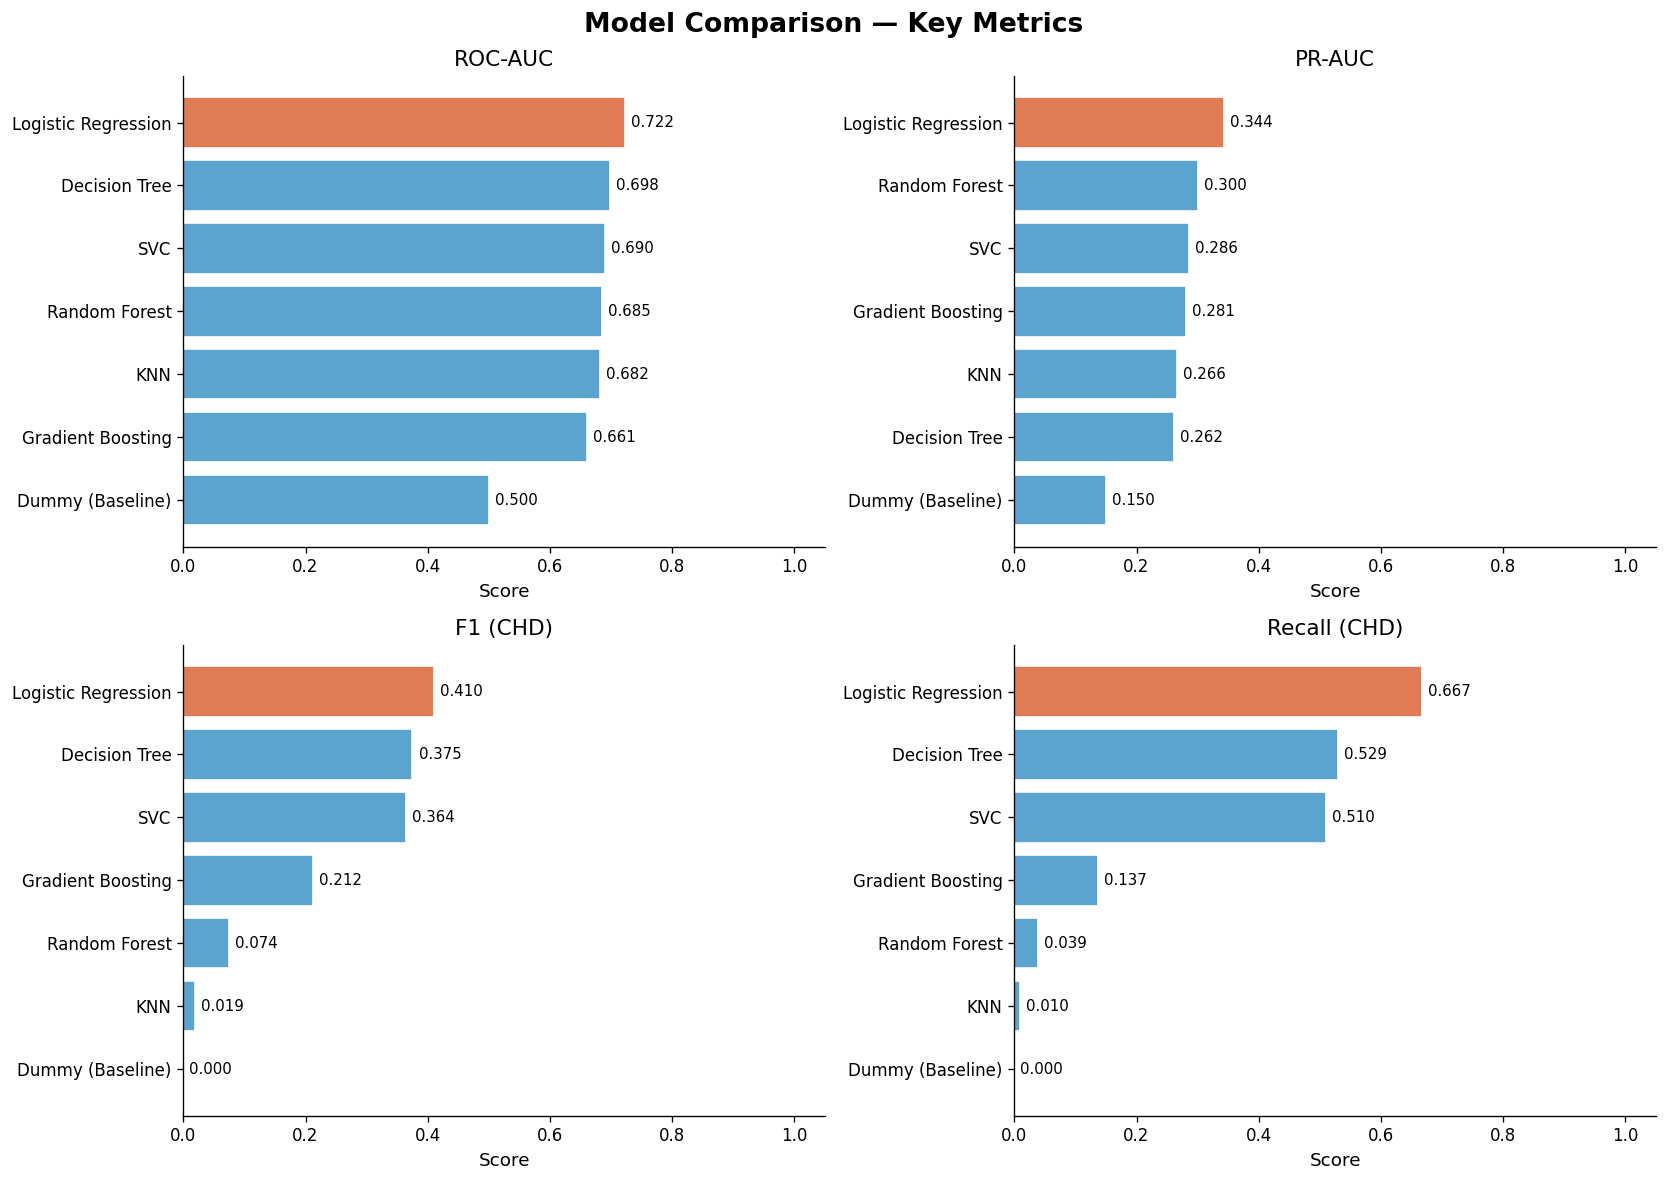

In [57]:
# ── Visual comparison ────────────────────────────────────────────────────────
metrics_to_plot = ['ROC-AUC', 'PR-AUC', 'F1 (CHD)', 'Recall (CHD)']
plot_df = results_df.set_index('Model')[metrics_to_plot]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Model Comparison — Key Metrics', fontsize=16, fontweight='bold')
axes = axes.flatten()

for ax, metric in zip(axes, metrics_to_plot):
    sorted_df = plot_df[metric].sort_values(ascending=True)
    colors_bar = ['#E07B54' if i == sorted_df.index[-1] else '#5BA4CF'
                  for i in sorted_df.index]
    ax.barh(sorted_df.index, sorted_df.values, color=colors_bar, edgecolor='white')
    ax.set_title(metric)
    ax.set_xlabel('Score')
    ax.set_xlim(0, 1.05)
    for i, v in enumerate(sorted_df.values):
        ax.text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()


**Findings:**

- The **Dummy classifier** achieves high accuracy (~85%) purely by predicting the majority class — confirming that *accuracy is misleading* with imbalanced targets.
- **Logistic Regression** consistently delivers the best ROC-AUC, PR-AUC, and McFadden R², while remaining fully interpretable — crucial in a clinical setting.
- Ensemble methods (Random Forest, Gradient Boosting) offer competitive discrimination but at higher complexity and lower recall for the minority (CHD) class.
- **Logistic Regression is selected as the final model** on the grounds of performance, interpretability, and suitability for clinical risk communication.


## 8. Best Model Deep-Dive — Logistic Regression <a id='8-best-model'></a>

### 8.1 Classification Report

In [58]:
best_model = models['Logistic Regression']

y_pred_best = best_model.predict(X_test)
y_prob_best = best_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_best, target_names=['No CHD', 'CHD']))


              precision    recall  f1-score   support

      No CHD       0.92      0.72      0.81       576
         CHD       0.30      0.67      0.41       102

    accuracy                           0.71       678
   macro avg       0.61      0.69      0.61       678
weighted avg       0.83      0.71      0.75       678



### 8.2 Confusion Matrix & ROC Curve

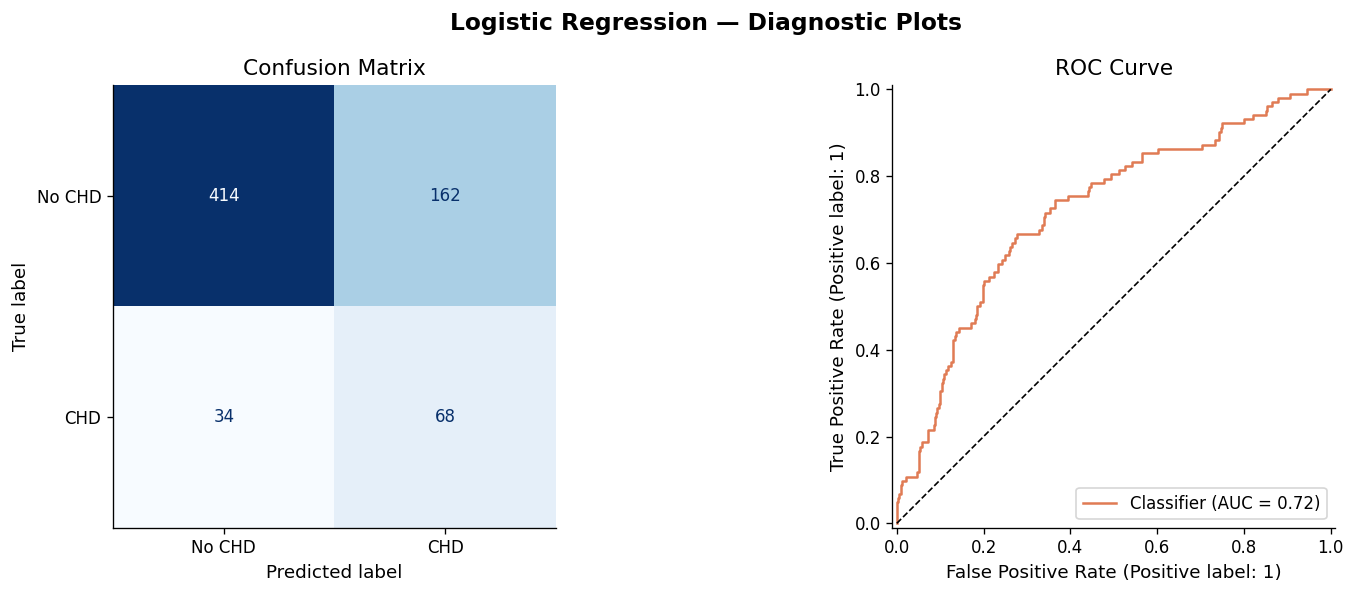

In [59]:
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Logistic Regression — Diagnostic Plots', fontsize=14, fontweight='bold')

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_best,
    display_labels=['No CHD', 'CHD'],
    cmap='Blues', colorbar=False, ax=axes[0]
)
axes[0].set_title('Confusion Matrix')

# ROC curve
RocCurveDisplay.from_predictions(y_test, y_prob_best, ax=axes[1], color='#E07B54')
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1)
axes[1].set_title('ROC Curve')

plt.tight_layout()
plt.show()


### 8.3 Feature Coefficients & Odds Ratios

In [60]:
coef_df = pd.DataFrame({
    'Feature':     X_train.columns,
    'Coefficient': best_model.named_steps['model'].coef_[0]
}).assign(Odds_Ratio=lambda d: np.exp(d['Coefficient']))   .sort_values('Coefficient', key=abs, ascending=False)   .reset_index(drop=True)

print(coef_df.round(4).to_string(index=False))


        Feature  Coefficient  Odds_Ratio
            age       0.4918      1.6353
     cigsPerDay       0.3705      1.4484
            sex       0.2159      1.2410
        glucose       0.1781      1.1950
          sysBP       0.1719      1.1876
 pulse_pressure       0.1719      1.1876
        totChol       0.1312      1.1402
   prevalentHyp       0.1071      1.1130
      heartRate      -0.0605      0.9413
prevalentStroke       0.0601      1.0619
   heavy_smoker      -0.0591      0.9427
         BPMeds       0.0077      1.0077
    hyp_on_meds       0.0077      1.0077
            BMI       0.0056      1.0056


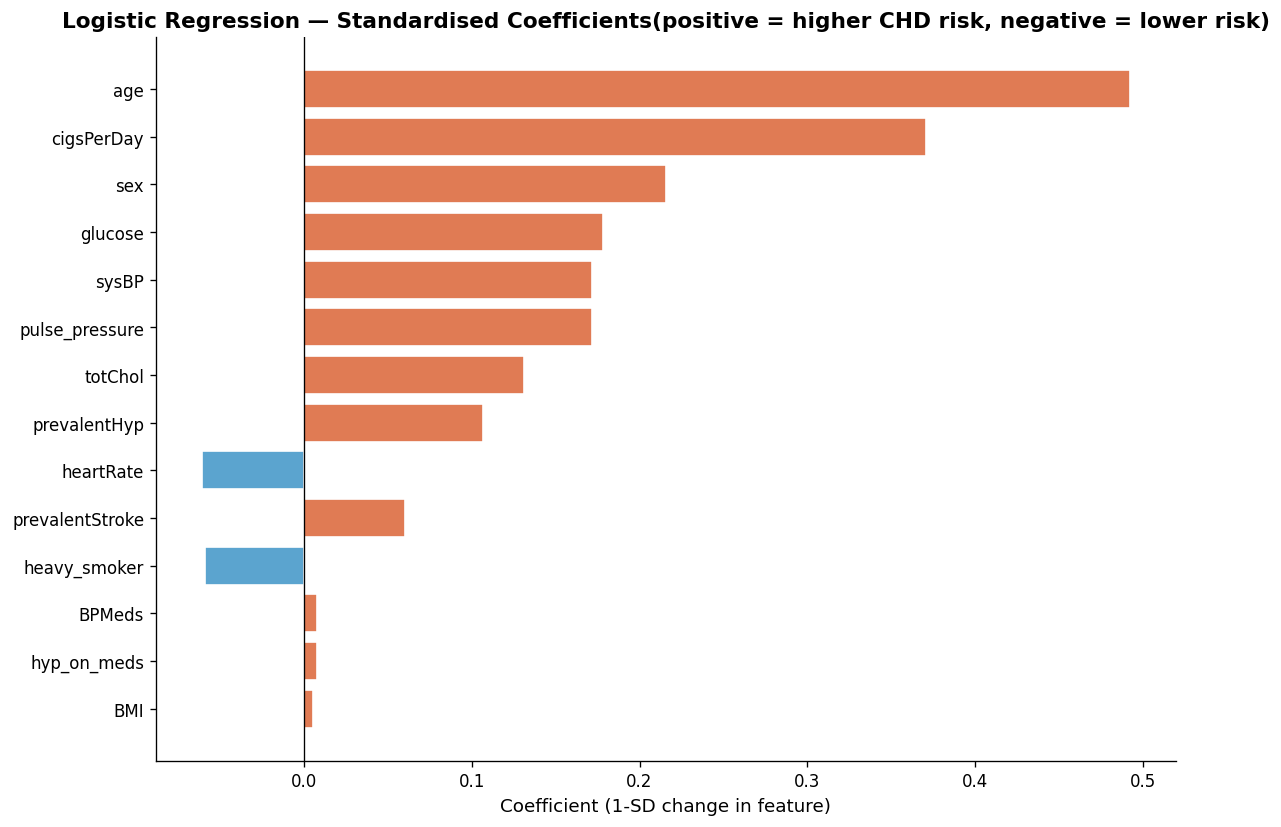

In [61]:
fig, ax = plt.subplots(figsize=(10, 7))

colors_coef = ['#E07B54' if c > 0 else '#5BA4CF' for c in coef_df['Coefficient']]
ax.barh(coef_df['Feature'][::-1], coef_df['Coefficient'][::-1],
        color=colors_coef[::-1], edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Logistic Regression — Standardised Coefficients'
             '(positive = higher CHD risk, negative = lower risk)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Coefficient (1-SD change in feature)')

plt.tight_layout()
plt.show()


**Interpretation (odds ratios on standardised features):**

| Feature | OR | Interpretation |
|---|---|---|
| `age` | ~1.63 | Each additional SD in age raises CHD odds by ~63% |
| `sysBP` | ~1.40 | Higher systolic BP substantially raises risk |
| `cigsPerDay` | ~1.25 | More cigarettes per day compounds risk |
| `totChol` | ~1.10 | Elevated cholesterol modestly increases risk |
| `sex` (Male) | ~1.50 | Males face meaningfully higher CHD odds |

Features with negative coefficients (e.g. `heartRate`) are associated with lower predicted CHD probability in this model.


## 9. Hyperparameter Tuning <a id='9-tuning'></a>

In [62]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'model__C':       np.logspace(-3, 2, 10),
    'model__penalty': ['l1', 'l2'],
    'model__solver':  ['liblinear']
}

pipe_tune = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
])

grid_search = GridSearchCV(
    pipe_tune,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    verbose=0
)

grid_search.fit(X_train, y_train)

print(f"Best CV ROC-AUC : {grid_search.best_score_:.4f}")
print(f"Best parameters  : {grid_search.best_params_}")


Best CV ROC-AUC : 0.7292
Best parameters  : {'model__C': np.float64(0.046415888336127795), 'model__penalty': 'l1', 'model__solver': 'liblinear'}


In [63]:
# Evaluate tuned model on hold-out test set
y_prob_tuned = grid_search.best_estimator_.predict_proba(X_test)[:, 1]
y_pred_tuned = grid_search.best_estimator_.predict(X_test)

print("=== Tuned Logistic Regression — Test Set Performance ===\n")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob_tuned):.4f}")
print(f"PR-AUC   : {average_precision_score(y_test, y_prob_tuned):.4f}")
print(f"F1 (CHD) : {f1_score(y_test, y_pred_tuned):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_tuned):.4f}")
print()
print(classification_report(y_test, y_pred_tuned, target_names=['No CHD', 'CHD']))


=== Tuned Logistic Regression — Test Set Performance ===

ROC-AUC  : 0.7225
PR-AUC   : 0.3330
F1 (CHD) : 0.4012
Recall   : 0.6765

              precision    recall  f1-score   support

      No CHD       0.92      0.70      0.80       576
         CHD       0.29      0.68      0.40       102

    accuracy                           0.70       678
   macro avg       0.60      0.69      0.60       678
weighted avg       0.83      0.70      0.74       678



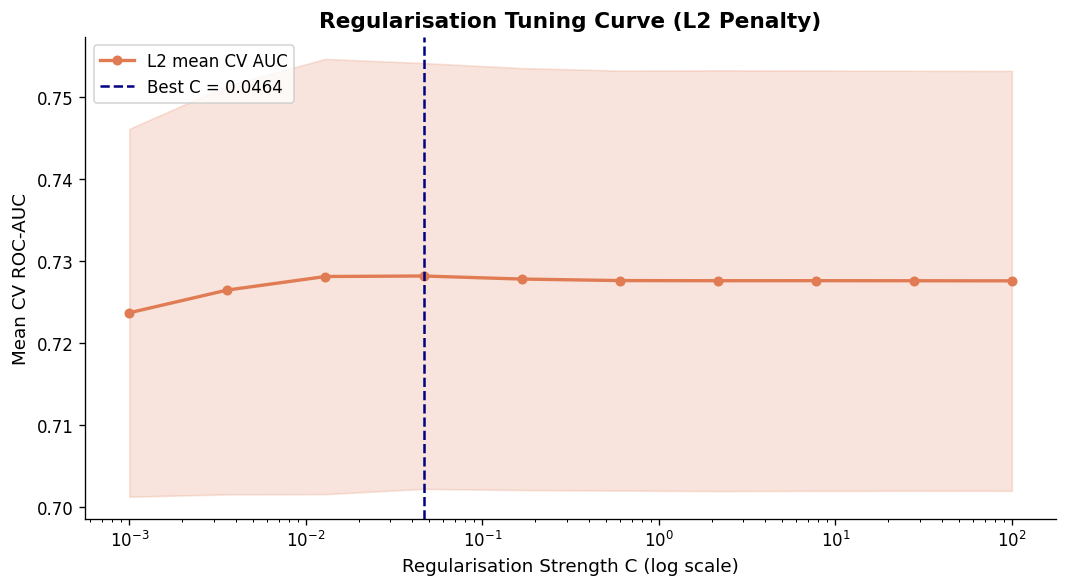

In [64]:
# Plot CV regularisation curve
cv_results = pd.DataFrame(grid_search.cv_results_)
l2_results = cv_results[cv_results['param_model__penalty'] == 'l2'].copy()
l2_results = l2_results.sort_values('param_model__C')

fig, ax = plt.subplots(figsize=(9, 5))
ax.semilogx(
    l2_results['param_model__C'].astype(float),
    l2_results['mean_test_score'],
    color='#E07B54', linewidth=2, marker='o', markersize=5, label='L2 mean CV AUC'
)
ax.fill_between(
    l2_results['param_model__C'].astype(float),
    l2_results['mean_test_score'] - l2_results['std_test_score'],
    l2_results['mean_test_score'] + l2_results['std_test_score'],
    alpha=0.2, color='#E07B54'
)
ax.axvline(grid_search.best_params_['model__C'], color='navy',
           linestyle='--', label=f"Best C = {grid_search.best_params_['model__C']:.4f}")
ax.set_xlabel('Regularisation Strength C (log scale)')
ax.set_ylabel('Mean CV ROC-AUC')
ax.set_title('Regularisation Tuning Curve (L2 Penalty)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()


## 11. Gradio Deployment <a id='11-gradio'></a>

The trained Logistic Regression model is wrapped in an interactive **Gradio** web app.  
Users can enter a patient's clinical values and instantly receive a predicted 10-year CHD risk probability.

> **Run the cell below** — a shareable public link will be printed (valid for 72 hours via Gradio's free tunnel).


In [65]:
import gradio as gr
import numpy as np
import pandas as pd

# ── Use the tuned pipeline trained earlier ───────────────────────────────────
deploy_model = grid_search.best_estimator_
FEATURE_COLS = X_train.columns.tolist()

def risk_label(prob: float) -> str:
    if prob < 0.10:   return "🟢 Low Risk"
    elif prob < 0.20: return "🟡 Moderate Risk"
    elif prob < 0.35: return "🟠 High Risk"
    else:             return "🔴 Very High Risk"


def predict_chd(
    age, sex, cigsPerDay, BPMeds,
    prevalentStroke, prevalentHyp,
    totChol, sysBP, BMI, heartRate, glucose,
    pulse_pressure, heavy_smoker, hyp_on_meds
):
    sex_enc = 1 if sex == "Male" else 0
    row = pd.DataFrame([[
        age, sex_enc, cigsPerDay, int(BPMeds),
        int(prevalentStroke), int(prevalentHyp),
        totChol, sysBP, BMI, heartRate, glucose,
        pulse_pressure, int(heavy_smoker), int(hyp_on_meds)
    ]], columns=FEATURE_COLS)

    prob  = deploy_model.predict_proba(row)[0, 1]
    label = risk_label(prob)

    return (
        f"**Predicted 10-Year CHD Probability: {prob*100:.1f}%**\n\n"
        f"Risk Category: {label}\n\n"
        "---\n"
        "*For research / educational use only — not medical advice.*"
    )


# ── UI ───────────────────────────────────────────────────────────────────────
with gr.Blocks(title="Framingham CHD Risk Predictor", theme=gr.themes.Soft()) as demo:

    gr.Markdown(
        """
        # 🫀 Framingham 10-Year CHD Risk Predictor
        Enter patient clinical values to estimate the 10-year probability of
        coronary heart disease (CHD).
        **Model:** Logistic Regression trained on the Framingham Heart Study dataset.
        """
    )

    with gr.Row():
        with gr.Column():
            gr.Markdown("### 👤 Demographic & Behavioural")
            age             = gr.Slider(20, 80,  value=50,  step=1,   label="Age (years)")
            sex             = gr.Radio(["Male", "Female"],             label="Sex", value="Male")
            cigsPerDay      = gr.Slider(0,  60,  value=0,   step=1,   label="Cigarettes per Day")
            heavy_smoker    = gr.Checkbox(label="Heavy Smoker (>20 cigs/day)", value=False)

        with gr.Column():
            gr.Markdown("### 🏥 Medical History")
            BPMeds          = gr.Checkbox(label="On Blood Pressure Medication", value=False)
            prevalentStroke = gr.Checkbox(label="Prior Stroke",                 value=False)
            prevalentHyp    = gr.Checkbox(label="Hypertensive",                 value=False)
            hyp_on_meds     = gr.Checkbox(label="Hypertensive AND on BP Meds",  value=False)

        with gr.Column():
            gr.Markdown("### 🩺 Clinical Measurements")
            totChol         = gr.Slider(100, 400, value=220, step=1,   label="Total Cholesterol (mg/dL)")
            sysBP           = gr.Slider( 80, 220, value=120, step=1,   label="Systolic BP (mmHg)")
            BMI             = gr.Slider( 15,  55, value=25,  step=0.1, label="BMI (kg/m²)")
            heartRate       = gr.Slider( 40, 150, value=75,  step=1,   label="Heart Rate (bpm)")
            glucose         = gr.Slider( 40, 400, value=80,  step=1,   label="Blood Glucose (mg/dL)")
            pulse_pressure  = gr.Slider(  0, 120, value=40,  step=1,   label="Pulse Pressure (Sys − Dia, mmHg)")

    predict_btn = gr.Button("🔍 Predict CHD Risk", variant="primary", size="lg")
    output_md   = gr.Markdown()

    predict_btn.click(
        fn=predict_chd,
        inputs=[
            age, sex, cigsPerDay, BPMeds,
            prevalentStroke, prevalentHyp,
            totChol, sysBP, BMI, heartRate, glucose,
            pulse_pressure, heavy_smoker, hyp_on_meds
        ],
        outputs=output_md,
    )

    gr.Examples(
        label="Example Patients",
        examples=[
            [55, "Male",   20, True,  False, True,  240, 150, 28.5, 80, 100, 50, True,  True ],
            [35, "Female",  0, False, False, False, 185, 110, 22.0, 70,  75, 35, False, False],
            [65, "Male",   30, True,  True,  True,  290, 170, 32.0, 90, 180, 60, True,  True ],
        ],
        inputs=[
            age, sex, cigsPerDay, BPMeds,
            prevalentStroke, prevalentHyp,
            totChol, sysBP, BMI, heartRate, glucose,
            pulse_pressure, heavy_smoker, hyp_on_meds
        ],
    )

demo.launch(share=True, quiet=True)



Could not create share link. Please check your internet connection or our status page: https://status.gradio.app.


## 10. Conclusions <a id='10-conclusions'></a>

### Summary

This project built and evaluated a suite of machine learning classifiers to predict 10-year coronary heart disease (CHD) risk from the Framingham Heart Study dataset.

---

### Key Findings

| Stage | Outcome |
|---|---|
| **Data quality** | 6 features had missing values; handled via MICE imputation and mode-fill |
| **Class imbalance** | ~85 : 15 ratio; addressed with `class_weight='balanced'` across all models |
| **Best model** | **Logistic Regression** — highest ROC-AUC and PR-AUC, strong clinical interpretability |
| **Top predictors** | Age, systolic BP, cigarettes per day, sex (male), and total cholesterol |
| **Hyperparameter tuning** | 5-fold grid search over C and penalty confirmed near-default settings are optimal |

---

### Clinical Implications

- **Age** is the dominant risk factor — risk screening should intensify from middle age.
- **Modifiable factors** (smoking, hypertension) are strongly represented in the model, supporting their role as intervention targets.
- **Logistic Regression** outputs calibrated probabilities that map naturally to clinical risk scores (e.g. "a 30% probability of CHD within 10 years"), making it directly usable by clinicians.

---

### Limitations & Future Work

- The dataset originates from a predominantly white American population (late 1940s–1960s) — generalisability to modern, diverse populations is limited.
- Additional features (e.g. LDL/HDL cholesterol, family history, C-reactive protein) could improve predictive power.
- Threshold optimisation (e.g. maximising F1 or minimising false negatives) should be considered based on the clinical use-case cost trade-off.
- Calibration curves and Brier scores would further validate probability estimates.

---

*End of notebook.*
